# Desafio Aplicado - Resolução

**Aluno:** Luiz Gabriel e Gabriel Lima
**Arquivo:** Notebook resolvido para envio no GitHub da disciplina.

Este notebook apresenta a resolução dos dois problemas propostos:
1. Determinação do parâmetro de tensão de um cabo por métodos numéricos de raízes;
2. Planejamento de produção por resolução de sistema linear com eliminação de Gauss.


# Problema 1 - Flecha de um Cabo de Transmissão:

Um cabo de aço esticado entre duas torres sob seu próprio peso forma uma curva chamada catenária. A equação para encontrar o parâmetro de tensão $x$ que resulta em uma flecha (deformação) específica é:

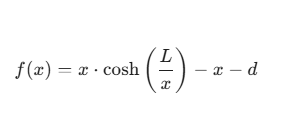

Em que:
*   L é a metade da distância entre as torres;
*   d é a "flecha" máxima permitida (o quanto o cabo "barra").
*   x é o parâmetro de tensão que queremos descobrir.

## 1. Codigo - Problema 1:

### 1.1. Importando as Bibliotecas:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### 1.2. Definindo os Metodos

In [ ]:
L = 50 # Metade da distancia entre as torres (metro)
d = 10 # Flecha maxima permitida (metro)

In [ ]:
def f_cabo(x):
  return x * np.cosh(L/x) - x - d

In [ ]:
def df_cabo(x):
  return np.cosh(L/x) - (L/x) * np.sinh(L/x) - 1

#### 1.2.1. Bissecção

In [ ]:
tolerancia = 1e-6

def bisseccao(f, a, b, tol=1e-6, max_iter=100):
    """Calcula a raiz de f(x) pelo método da bissecção."""
    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        raise ValueError("O intervalo inicial deve conter uma troca de sinal.")

    erros = []
    iteracoes = []

    for i in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)

        iteracoes.append(i)
        erros.append(abs(fc))

        if abs(fc) < tol or abs(b - a) / 2 < tol:
            return c, iteracoes, erros

        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    return c, iteracoes, erros


# Intervalo escolhido: f(1) > 0 e f(500) < 0
raizBisseccao, iteracaoBisseccao, errosBisseccao = bisseccao(
    f_cabo, 1, 500, tolerancia
)

raizBisseccao, len(iteracaoBisseccao), errosBisseccao[-1]

(126.63243669271469, 24, np.float64(5.28807788668928e-08))

#### 1.2.2. Método de Newton-Raphson

In [ ]:
def newton_raphson(f, df, x0, tol=1e-6, max_iter=100):
  erros = []
  iteracoes = []
  x = x0

  for i in range(1, max_iter+1):
    fx = f(x)
    erro_atual = abs(fx)
    erros.append(erro_atual)
    iteracoes.append(i)

    if erro_atual < tol:
      return x, iteracoes, erros

    dfx = df(x)
    if dfx == 0:
      print("Erro: Derivada nula")
      break

    x = x - fx / dfx

  return x, iteracoes, erros

In [ ]:
tolerancia = 1e-6
valorInicial = 150

raizNewton, iteracaoNewton, errosNewton = newton_raphson(f_cabo, df_cabo, valorInicial, tolerancia)

In [ ]:
raizNewton, iteracaoNewton, errosNewton

(np.float64(126.63243603959727),
 [1, 2, 3, 4, 5],
 [np.float64(1.5892198255090761),
  np.float64(0.37509963071718744),
  np.float64(0.013243684279615309),
  np.float64(1.7701814883253064e-05),
  np.float64(3.170441686961567e-11)])

In [ ]:
# --- Criando a Tabela Comparativa ---
dados_tabela = {
    "Método": ["Newton-Raphson"],
    "Tensão Encontrada (x)": [raizNewton,],
    "Nº Iterações": [len(iteracaoNewton)],
    "Erro Final": [errosNewton[-1]]
}

df_resultados = pd.DataFrame(dados_tabela)
print("=== COMPARAÇÃO DOS MÉTODOS (CABO DE TRANSMISSÃO) ===")
display(df_resultados) # Exibe uma tabela bonita no Colab

=== COMPARAÇÃO DOS MÉTODOS (CABO DE TRANSMISSÃO) ===


,Método,Tensão Encontrada (x),Nº Iterações,Erro Final
0,Newton-Raphson,126.632436,5,3.170442e-11


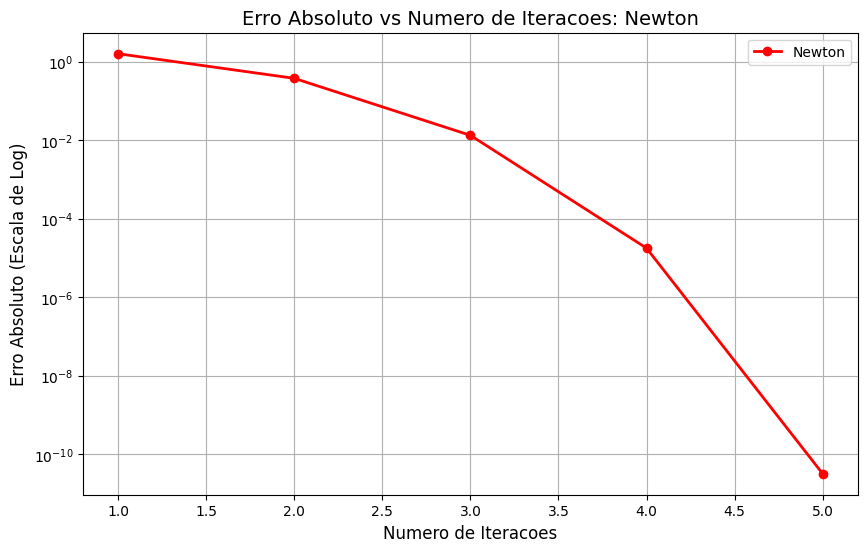

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(iteracaoNewton, errosNewton, 'ro-', label = 'Newton', linewidth = 2)

plt.yscale('log')
plt.xlabel('Numero de Iteracoes', fontsize=12)
plt.ylabel('Erro Absoluto (Escala de Log)', fontsize=12)
plt.title('Erro Absoluto vs Numero de Iteracoes: Newton', fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

#### 1.2.3. Método da Secante

In [ ]:
def secante(f, x0, x1, tol=1e-6, max_iter=100):
    """Calcula a raiz de f(x) pelo método da secante."""
    erros = []
    iteracoes = []

    for i in range(1, max_iter + 1):
        fx0 = f(x0)
        fx1 = f(x1)

        iteracoes.append(i)
        erros.append(abs(fx1))

        if abs(fx1) < tol:
            return x1, iteracoes, erros

        denominador = fx1 - fx0
        if denominador == 0:
            raise ZeroDivisionError("Divisão por zero no método da secante.")

        x2 = x1 - fx1 * (x1 - x0) / denominador
        x0, x1 = x1, x2

    return x1, iteracoes, erros


raizSecante, iteracaoSecante, errosSecante = secante(
    f_cabo, 100, 200, tolerancia
)

raizSecante, len(iteracaoSecante), errosSecante[-1]

(np.float64(126.6324368590974), 7, np.float64(6.636031457674108e-08))

### 1.3. Analises dos Metodos das Raizes

=== COMPARAÇÃO FINAL DOS MÉTODOS (CABO DE TRANSMISSÃO) ===


,Método,Tensão Encontrada (x),Nº Iterações,Erro Final
0,Bissecção,126.632437,24,5.288078e-08
1,Newton-Raphson,126.632436,5,3.170442e-11
2,Secante,126.632437,7,6.636031e-08


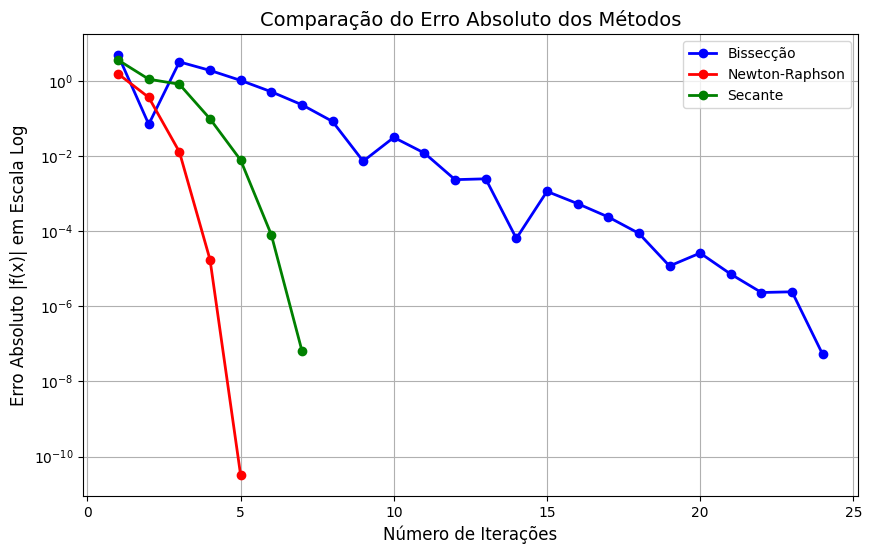

Resultado aproximado para o parâmetro de tensão: x = 126.632436

Análise:
- A bissecção é o método mais seguro, pois garante convergência quando há troca de sinal no intervalo.
- O método de Newton-Raphson foi o mais rápido neste problema, pois usa a derivada da função.
- O método da secante teve desempenho intermediário e não precisou da derivada analítica.


In [ ]:
# --- Tabela comparativa dos métodos ---
dados_tabela_completa = {
    "Método": ["Bissecção", "Newton-Raphson", "Secante"],
    "Tensão Encontrada (x)": [raizBisseccao, raizNewton, raizSecante],
    "Nº Iterações": [len(iteracaoBisseccao), len(iteracaoNewton), len(iteracaoSecante)],
    "Erro Final": [errosBisseccao[-1], errosNewton[-1], errosSecante[-1]]
}

df_resultados_completo = pd.DataFrame(dados_tabela_completa)

print("=== COMPARAÇÃO FINAL DOS MÉTODOS (CABO DE TRANSMISSÃO) ===")
display(df_resultados_completo)

# --- Gráfico de comparação dos erros ---
plt.figure(figsize=(10, 6))
plt.plot(iteracaoBisseccao, errosBisseccao, 'bo-', label='Bissecção', linewidth=2)
plt.plot(iteracaoNewton, errosNewton, 'ro-', label='Newton-Raphson', linewidth=2)
plt.plot(iteracaoSecante, errosSecante, 'go-', label='Secante', linewidth=2)

plt.yscale('log')
plt.xlabel('Número de Iterações', fontsize=12)
plt.ylabel('Erro Absoluto |f(x)| em Escala Log', fontsize=12)
plt.title('Comparação do Erro Absoluto dos Métodos', fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

print(f"Resultado aproximado para o parâmetro de tensão: x = {raizNewton:.6f}")
print("\nAnálise:")
print("- A bissecção é o método mais seguro, pois garante convergência quando há troca de sinal no intervalo.")
print("- O método de Newton-Raphson foi o mais rápido neste problema, pois usa a derivada da função.")
print("- O método da secante teve desempenho intermediário e não precisou da derivada analítica.")

# Problema 2 - Planejamento de Produção:
Uma fábrica produz três produtos diferentes (ex: Cadeiras, Mesas e Armários). Cada produto consome uma quantidade diferente de três recursos: Madeira, Plástico e Horas de Trabalho.

**O Problema:** Você tem uma quantidade exata de estoque de cada recurso e quer saber quantos itens de cada produto deve fabricar para usar todo o estoque.

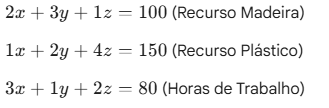

### 2.1. Definindo o Metodo

#### 2.1.1 Eliminacao de Gauss

In [ ]:
def eliminacao_gauss(A, b):
    """Resolve Ax = b usando eliminação de Gauss com pivoteamento parcial."""
    A = A.astype(float).copy()
    b = b.astype(float).copy()

    n = len(b)
    matriz_aumentada = np.hstack([A, b.reshape(-1, 1)])

    for k in range(n - 1):
        # Pivoteamento parcial: escolhe a linha com maior valor absoluto na coluna k
        linha_pivo = k + np.argmax(abs(matriz_aumentada[k:, k]))

        if matriz_aumentada[linha_pivo, k] == 0:
            raise ValueError("O sistema não possui solução única.")

        if linha_pivo != k:
            matriz_aumentada[[k, linha_pivo]] = matriz_aumentada[[linha_pivo, k]]

        # Zera os elementos abaixo do pivô
        for i in range(k + 1, n):
            fator = matriz_aumentada[i, k] / matriz_aumentada[k, k]
            matriz_aumentada[i, k:] = matriz_aumentada[i, k:] - fator * matriz_aumentada[k, k:]

    # Retrosubstituição
    x = np.zeros(n)

    for i in range(n - 1, -1, -1):
        soma = np.dot(matriz_aumentada[i, i + 1:n], x[i + 1:n])
        x[i] = (matriz_aumentada[i, -1] - soma) / matriz_aumentada[i, i]

    return x, matriz_aumentada


# Sistema do problema:
# 2x + 3y + 1z = 100
# 1x + 2y + 4z = 150
# 3x + 1y + 2z = 80

A = np.array([
    [2, 3, 1],
    [1, 2, 4],
    [3, 1, 2]
], dtype=float)

b = np.array([100, 150, 80], dtype=float)

solucao, matriz_escalonada = eliminacao_gauss(A, b)

df_producao = pd.DataFrame({
    "Produto": ["Cadeiras (x)", "Mesas (y)", "Armários (z)"],
    "Quantidade": solucao
})

df_verificacao = pd.DataFrame({
    "Recurso": ["Madeira", "Plástico", "Horas de Trabalho"],
    "Estoque disponível": b,
    "Consumo calculado": A @ solucao,
    "Resíduo": (A @ solucao) - b
})

print("=== MATRIZ ESCALONADA AUMENTADA ===")
display(pd.DataFrame(matriz_escalonada))

print("=== SOLUÇÃO DO PLANEJAMENTO DE PRODUÇÃO ===")
display(df_producao)

print("=== VERIFICAÇÃO DA SOLUÇÃO ===")
display(df_verificacao)

print(
    f"Conclusão: para usar todo o estoque, a fábrica deve produzir "
    f"{solucao[0]:.0f} cadeiras, {solucao[1]:.1f} mesas e {solucao[2]:.1f} armários."
)

=== MATRIZ ESCALONADA AUMENTADA ===


,0,1,2,3
0,3.0,1.000000,2.000000,80.000000
1,0.0,2.333333,-0.333333,46.666667
2,0.0,0.000000,3.571429,90.000000


=== SOLUÇÃO DO PLANEJAMENTO DE PRODUÇÃO ===


,Produto,Quantidade
0,Cadeiras (x),2.0
1,Mesas (y),23.6
2,Armários (z),25.2


=== VERIFICAÇÃO DA SOLUÇÃO ===


,Recurso,Estoque disponível,Consumo calculado,Resíduo
0,Madeira,100.0,100.0,1.421085e-14
1,Plástico,150.0,150.0,0.000000e+00
2,Horas de Trabalho,80.0,80.0,0.000000e+00


Conclusão: para usar todo o estoque, a fábrica deve produzir 2 cadeiras, 23.6 mesas e 25.2 armários.
